Cellule 1 — Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
import warnings
warnings.filterwarnings('ignore')

Cellule 2 — Chargement du Dataset

In [2]:
# Chargement des deux datasets
mat = pd.read_csv('../data/student-mat.csv', sep=';')
por = pd.read_csv('../data/student-por.csv', sep=';')

# Ajouter une colonne pour identifier la source
mat['source'] = 'math'
por['source'] = 'portuguese'

print(f'📘 student-mat : {mat.shape[0]} lignes, {mat.shape[1]} colonnes')
print(f'📗 student-por : {por.shape[0]} lignes, {por.shape[1]} colonnes')

# Fusionner les deux datasets
df = pd.concat([mat, por], ignore_index=True)

print(f'\n✅ Dataset combiné : {df.shape[0]} lignes, {df.shape[1]} colonnes')
print(f'   → math       : {len(df[df["source"]=="math"])} étudiants')
print(f'   → portuguese : {len(df[df["source"]=="portuguese"])} étudiants')
df.head()

📘 student-mat : 395 lignes, 34 colonnes
📗 student-por : 649 lignes, 34 colonnes

✅ Dataset combiné : 1044 lignes, 34 colonnes
   → math       : 395 étudiants
   → portuguese : 649 étudiants


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,source
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,3,4,1,1,3,6,5,6,6,math
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,3,3,1,1,3,4,5,5,6,math
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,3,2,2,3,3,10,7,8,10,math
3,GP,F,15,U,GT3,T,4,2,health,services,...,2,2,1,1,5,2,15,14,15,math
4,GP,F,16,U,GT3,T,3,3,other,other,...,3,2,1,2,5,4,6,10,10,math


Cellule 3 — Exploration Rapide

In [3]:
print('=== SHAPE ===')
print(df.shape)

print('\n=== TYPES DES COLONNES ===')
print(df.dtypes)

print('\n=== STATISTIQUES DESCRIPTIVES ===')
df.describe()

=== SHAPE ===
(1044, 34)

=== TYPES DES COLONNES ===
school        object
sex           object
age            int64
address       object
famsize       object
Pstatus       object
Medu           int64
Fedu           int64
Mjob          object
Fjob          object
reason        object
guardian      object
traveltime     int64
studytime      int64
failures       int64
schoolsup     object
famsup        object
paid          object
activities    object
nursery       object
higher        object
internet      object
romantic      object
famrel         int64
freetime       int64
goout          int64
Dalc           int64
Walc           int64
health         int64
absences       int64
G1             int64
G2             int64
G3             int64
source        object
dtype: object

=== STATISTIQUES DESCRIPTIVES ===


,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000
mean,16.726054,2.603448,2.387931,1.522989,1.970307,0.264368,3.935824,3.201149,3.156130,1.494253,2.284483,3.543103,4.434866,11.213602,11.246169,11.341954
std,1.239975,1.124907,1.099938,0.731727,0.834353,0.656142,0.933401,1.031507,1.152575,0.911714,1.285105,1.424703,6.210017,2.983394,3.285071,3.864796
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,16.000000,2.000000,1.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,9.000000,9.000000,10.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,2.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,6.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


Cellule 4 — Suppression des Colonnes Inutiles

In [4]:
# Colonnes à garder : assiduité + notes + participation + target
cols_to_keep = [
    'absences',    # assiduité
    'G1',          # note examen 1
    'G2',          # note examen 2
    'G3',          # note finale (pour créer la target plus tard)
    'studytime',   # temps d'étude
    'failures',    # échecs passés
    'activities',  # participation extra-scolaire
    'higher',      # ambition études supérieures
    'source',      # math ou portugais
]

# Colonnes supprimées
cols_dropped = [col for col in df.columns if col not in cols_to_keep]
print(f'❌ Colonnes supprimées ({len(cols_dropped)}) :')
for col in cols_dropped:
    print(f'   - {col}')

df = df[cols_to_keep]

print(f'\n✅ Colonnes gardées ({len(cols_to_keep)}) : {cols_to_keep}')
print(f'\n📊 Nouveau shape : {df.shape}')
df.head()

❌ Colonnes supprimées (25) :
   - school
   - sex
   - age
   - address
   - famsize
   - Pstatus
   - Medu
   - Fedu
   - Mjob
   - Fjob
   - reason
   - guardian
   - traveltime
   - schoolsup
   - famsup
   - paid
   - nursery
   - internet
   - romantic
   - famrel
   - freetime
   - goout
   - Dalc
   - Walc
   - health

✅ Colonnes gardées (9) : ['absences', 'G1', 'G2', 'G3', 'studytime', 'failures', 'activities', 'higher', 'source']

📊 Nouveau shape : (1044, 9)


,absences,G1,G2,G3,studytime,failures,activities,higher,source
0,6,5,6,6,2,0,no,yes,math
1,4,5,5,6,2,0,no,yes,math
2,10,7,8,10,2,3,no,yes,math
3,2,15,14,15,3,0,yes,yes,math
4,4,6,10,10,2,0,no,yes,math


Cellule 4 — Vérification des Valeurs Manquantes

In [5]:
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Valeurs manquantes': missing,
    'Pourcentage (%)': missing_pct
})

print('=== VALEURS MANQUANTES ===')
print(missing_df[missing_df['Valeurs manquantes'] > 0])

if missing.sum() == 0:
    print('\n✅ Aucune valeur manquante dans ce dataset !')
else:
    print(f'\n⚠️ Total valeurs manquantes : {missing.sum()}')

=== VALEURS MANQUANTES ===
Empty DataFrame
Columns: [Valeurs manquantes, Pourcentage (%)]
Index: []

✅ Aucune valeur manquante dans ce dataset !


Cellule 6 — Suppression des Doublons

In [6]:
avant = df.shape[0]

# On supprime les doublons basés sur les colonnes qu'on a gardées
df.drop_duplicates(inplace=True)
apres = df.shape[0]

print(f'Lignes avant       : {avant}')
print(f'Lignes après       : {apres}')
print(f'Doublons supprimés : {avant - apres}')

print(f'\n   → math       : {len(df[df["source"]=="math"])} étudiants')
print(f'   → portuguese : {len(df[df["source"]=="portuguese"])} étudiants')

if avant == apres:
    print('\n✅ Aucun doublon trouvé !')

Lignes avant       : 1044
Lignes après       : 986
Doublons supprimés : 58

   → math       : 387 étudiants
   → portuguese : 599 étudiants


Cellule 7 — Création de la Variable Cible (Target)

Distribution de la variable cible :
pass
1    593
0    393
Name: count, dtype: int64

Taux de réussite : 60.1%


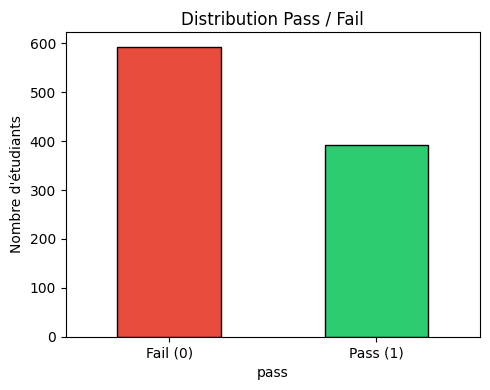

In [ ]:
# Score global pondéré (sur 10)
df['score'] = (
    df['G1'] * 0.20 +   # note exam 1 → 20%
    df['G2'] * 0.20 +   # note exam 2 → 20%
    df['G3'] * 0.60     # note finale → 60%
)

# Pénalité absences (trop d'absences → impact négatif)
df['score'] = df['score'] - (df['absences'] * 0.1)

# Pénalité failures
df['score'] = df['score'] - (df['failures'] * 0.5)

# Pass = 1 si score >= 10, sinon 0
df['pass'] = (df['score'] >= 10).astype(int)

print('Distribution de la variable cible :')
print(df['pass'].value_counts())
print(f'\nTaux de réussite : {df["pass"].mean()*100:.1f}%')

# Visualisation
plt.figure(figsize=(5,4))
df['pass'].value_counts().plot(kind='bar', color=['#e74c3c', '#2ecc71'], edgecolor='black')
plt.title('Distribution Pass / Fail')
plt.xticks([0, 1], ['Fail (0)', 'Pass (1)'], rotation=0)
plt.ylabel("Nombre d'étudiants")
plt.tight_layout()
plt.savefig('../data/target_distribution.png', dpi=100)
plt.show()

Cellule 8 — Encodage des Colonnes Binaires (yes/no, M/F...)

In [8]:
# Seulement les colonnes binaires restantes après suppression
binary_mappings = {
    'activities': {'no': 0, 'yes': 1},
    'higher'    : {'no': 0, 'yes': 1},
    'source'    : {'math': 0, 'portuguese': 1},
}

for col, mapping in binary_mappings.items():
    if col in df.columns:
        df[col] = df[col].map(mapping)
        print(f'✅ {col} encodé')

print('\n✅ Encodage binaire terminé !')

✅ activities encodé
✅ higher encodé
✅ source encodé

✅ Encodage binaire terminé !


Cellule 10 — Normalisation des Colonnes Numériques

In [9]:
from sklearn.preprocessing import StandardScaler

# Colonnes numériques à scaler (hors target G3 et 'pass')
num_cols_to_scale = ['absences', 'G1', 'G2', 'studytime', 'failures']

scaler = StandardScaler()
df[num_cols_to_scale] = scaler.fit_transform(df[num_cols_to_scale])

print('✅ StandardScaler appliqué sur les colonnes numériques')
print('\nAperçu après scaling :')
df[num_cols_to_scale].describe().round(2)

✅ StandardScaler appliqué sur les colonnes numériques

Aperçu après scaling :


,absences,G1,G2,studytime,failures
count,986.00,986.00,986.00,986.00,986.00
mean,0.00,-0.00,-0.00,0.00,-0.00
std,1.00,1.00,1.00,1.00,1.00
min,-0.73,-3.69,-3.35,-1.14,-0.42
25%,-0.73,-0.72,-0.66,-1.14,-0.42
50%,-0.41,-0.06,-0.06,0.04,-0.42
75%,0.22,0.61,0.54,0.04,-0.42
max,11.14,2.59,2.34,2.40,4.05


Cellule 11 — Séparation Features / Target + Train/Test Split

In [10]:
from sklearn.model_selection import train_test_split

# Supprimer G3 (c'est la note brute, on garde 'pass' comme target)
X = df.drop(columns=['G3', 'pass'])
y = df['pass']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'✅ Split effectué :')
print(f'   X_train : {X_train.shape}')
print(f'   X_test  : {X_test.shape}')
print(f'   y_train : {y_train.shape}')
print(f'   y_test  : {y_test.shape}')
print(f'\n   Taux de réussite train : {y_train.mean()*100:.1f}%')
print(f'   Taux de réussite test  : {y_test.mean()*100:.1f}%')

✅ Split effectué :
   X_train : (788, 9)
   X_test  : (198, 9)
   y_train : (788,)
   y_test  : (198,)

   Taux de réussite train : 60.2%
   Taux de réussite test  : 60.1%


Cellule 12 — Sauvegarde du Dataset Nettoyé

In [11]:
import pickle
import os

# Créer les dossiers s'ils n'existent pas
os.makedirs('../data', exist_ok=True)
os.makedirs('../models', exist_ok=True)

# Sauvegarder le dataset nettoyé
df.to_csv('../data/student_clean.csv', index=False)

# Sauvegarder les splits pour réutilisation
splits = {
    'X_train': X_train,
    'X_test' : X_test,
    'y_train': y_train,
    'y_test' : y_test
}
with open('../data/splits.pkl', 'wb') as f:
    pickle.dump(splits, f)

# Sauvegarder le scaler pour l'API
with open('../models/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print('✅ Dataset nettoyé sauvegardé → data/student_clean.csv')
print('✅ Splits sauvegardés         → data/splits.pkl')
print('✅ Scaler sauvegardé          → models/scaler.pkl')
print(f'\n📊 Résumé final du dataset propre :')
print(f'   Lignes    : {df.shape[0]} (mat + por combinés)')
print(f'   Colonnes  : {df.shape[1]}')
print(f'   Target    : pass (0=Fail, 1=Pass)')

✅ Dataset nettoyé sauvegardé → data/student_clean.csv
✅ Splits sauvegardés         → data/splits.pkl
✅ Scaler sauvegardé          → models/scaler.pkl

📊 Résumé final du dataset propre :
   Lignes    : 986 (mat + por combinés)
   Colonnes  : 11
   Target    : pass (0=Fail, 1=Pass)


Cellule MLflow

In [12]:
import mlflow

# Démarrer une run MLflow pour le preprocessing
mlflow.set_experiment("Student Performance - Preprocessing")

with mlflow.start_run(run_name="data_preprocessing"):

    # ── Infos dataset ──────────────────────────────────────
    mlflow.log_param("dataset_sources", "student-mat + student-por")
    mlflow.log_param("target", "pass (G3 >= 10)")
    mlflow.log_param("train_test_split", "80/20")
    mlflow.log_param("random_state", 42)
    mlflow.log_param("scaler", "StandardScaler")

    # ── Features gardées ───────────────────────────────────
    mlflow.log_param("features", list(X.columns))
    mlflow.log_param("nb_features", X.shape[1])

    # ── Métriques dataset ──────────────────────────────────
    mlflow.log_metric("total_rows", df.shape[0])
    mlflow.log_metric("train_rows", X_train.shape[0])
    mlflow.log_metric("test_rows", X_test.shape[0])
    mlflow.log_metric("pass_rate", round(y.mean() * 100, 2))
    mlflow.log_metric("fail_rate", round((1 - y.mean()) * 100, 2))
    mlflow.log_metric("missing_values", df.isnull().sum().sum())
    mlflow.log_metric("duplicates_removed", avant - apres)

    # ── Sauvegarder le CSV propre comme artifact ───────────
    mlflow.log_artifact('../data/student_clean.csv')
    mlflow.log_artifact('../data/target_distribution.png')

    print('✅ Preprocessing loggé dans MLflow !')
    print('👉 Lance : mlflow ui  →  http://localhost:5000')


2026/02/27 09:39:40 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.schemas
2026/02/27 09:39:40 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.tables
2026/02/27 09:39:40 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.types
2026/02/27 09:39:40 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.constraints
2026/02/27 09:39:40 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.defaults
2026/02/27 09:39:40 INFO alembic.runtime.plugins: setup plugin alembic.autogenerate.comments
2026/02/27 09:39:40 INFO alembic.runtime.migration: Context impl SQLiteImpl.
2026/02/27 09:39:40 INFO alembic.runtime.migration: Will assume non-transactional DDL.


✅ Preprocessing loggé dans MLflow !
👉 Lance : mlflow ui  →  http://localhost:5000
